# **IMPORTING LIBRARIES and Loading the dataset**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import table
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import Lasso, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")


from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor


from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool, cv
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import GridSearchCV, cross_val_score

In [3]:
df = pd.read_csv('/kaggle/input/predict-lifespan-of-a-comet-goldfish/fish_data.csv')

In [4]:
df.head()

,id,average_length(inches)),average_weight(inches)),habitat,ph_of_water,color,Gender,life_span
0,1,14.69,5.87,ponds,6.2,Reddish_Orange,False,10.9
1,2,1.32,3.86,idlewater,6.8,Calico,True,5.2
2,3,14.23,12.09,lakes,7.9,Reddish_Orange,True,25.3
3,4,2.54,3.20,rivers,6.7,White,False,16.4
4,5,13.10,9.81,lakes,7.8,Orange,True,3.2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       2000 non-null   int64  
 1   average_length(inches))  2000 non-null   float64
 2   average_weight(inches))  2000 non-null   float64
 3   habitat                  2000 non-null   object 
 4   ph_of_water              2000 non-null   float64
 5   color                    2000 non-null   object 
 6   Gender                   1976 non-null   object 
 7   life_span                2000 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 125.1+ KB


In [6]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,2000.0,1000.500000,577.494589,1.0,500.7500,1000.500,1500.2500,2000.00
average_length(inches)),2000.0,10.557110,5.521147,1.0,5.8575,10.660,15.1725,20.00
average_weight(inches)),2000.0,10.449445,4.885487,2.0,6.1375,10.455,14.6650,18.96
ph_of_water,2000.0,7.014950,0.577450,6.0,6.5000,7.000,7.5000,8.00
life_span,2000.0,14.371500,7.705953,1.0,7.8000,14.400,20.9000,28.00


In [7]:
df.shape

(2000, 8)

In [8]:
#Check for null values in the dataset
df.isnull().sum()

id                          0
average_length(inches))     0
average_weight(inches))     0
habitat                     0
ph_of_water                 0
color                       0
Gender                     24
life_span                   0
dtype: int64

In [9]:
# Drop rows with null values in-place
df.dropna(inplace=True)

# Display the shape of the modified DataFrame
df.shape


(1976, 8)

In [10]:
df.duplicated().sum()

0

In [11]:
#Checking the number of unique values
df.select_dtypes(include='int64').nunique()

id    1976
dtype: int64

In [12]:
#Checking the number of unique values
df.select_dtypes(include='float64').nunique()

average_length(inches))    1239
average_weight(inches))    1187
ph_of_water                  21
life_span                   271
dtype: int64

In [13]:
#Checking the number of unique values
df.select_dtypes(include='object').nunique()

habitat    5
color      9
Gender     2
dtype: int64

In [14]:
column_names = df.columns.tolist()
print("Column Names:")
print(column_names)


Column Names:
['id', 'average_length(inches))', 'average_weight(inches))', 'habitat', 'ph_of_water', 'color', 'Gender', 'life_span']


# **DATA VISUALIZATION**

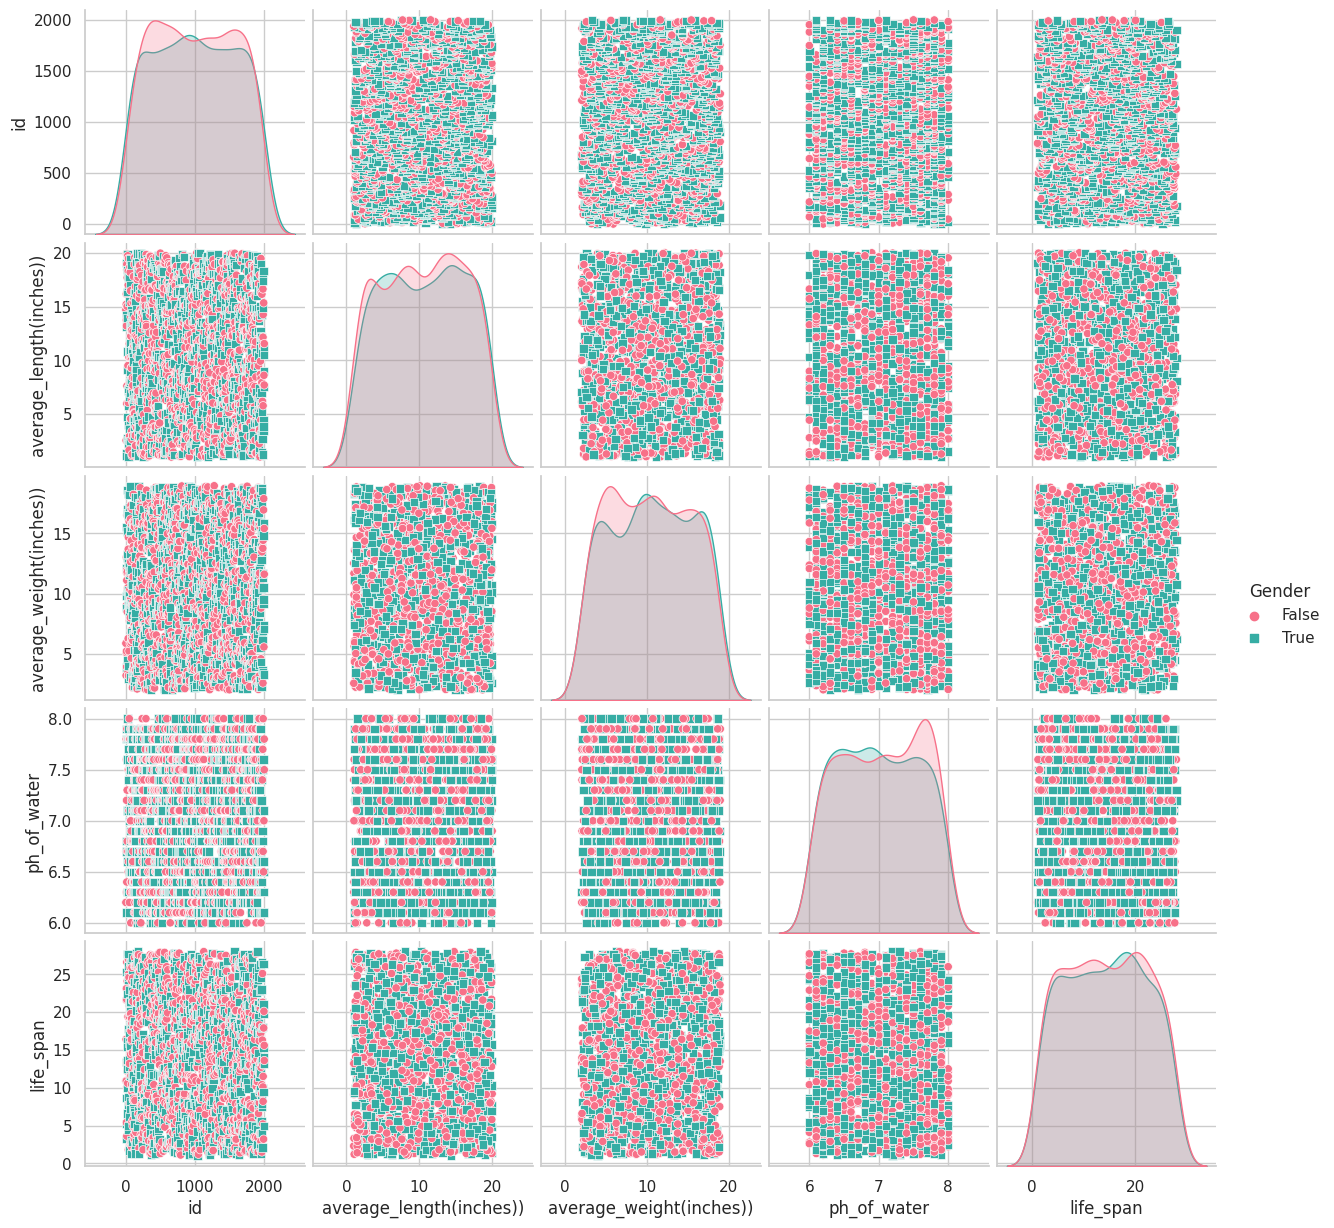

In [15]:
# Set the style for seaborn
sns.set(style="whitegrid")

# Scatter plot matrix
sns.pairplot(df, hue="Gender", palette="husl", markers=["o", "s"], diag_kind="kde")

# Display the plot
plt.show()


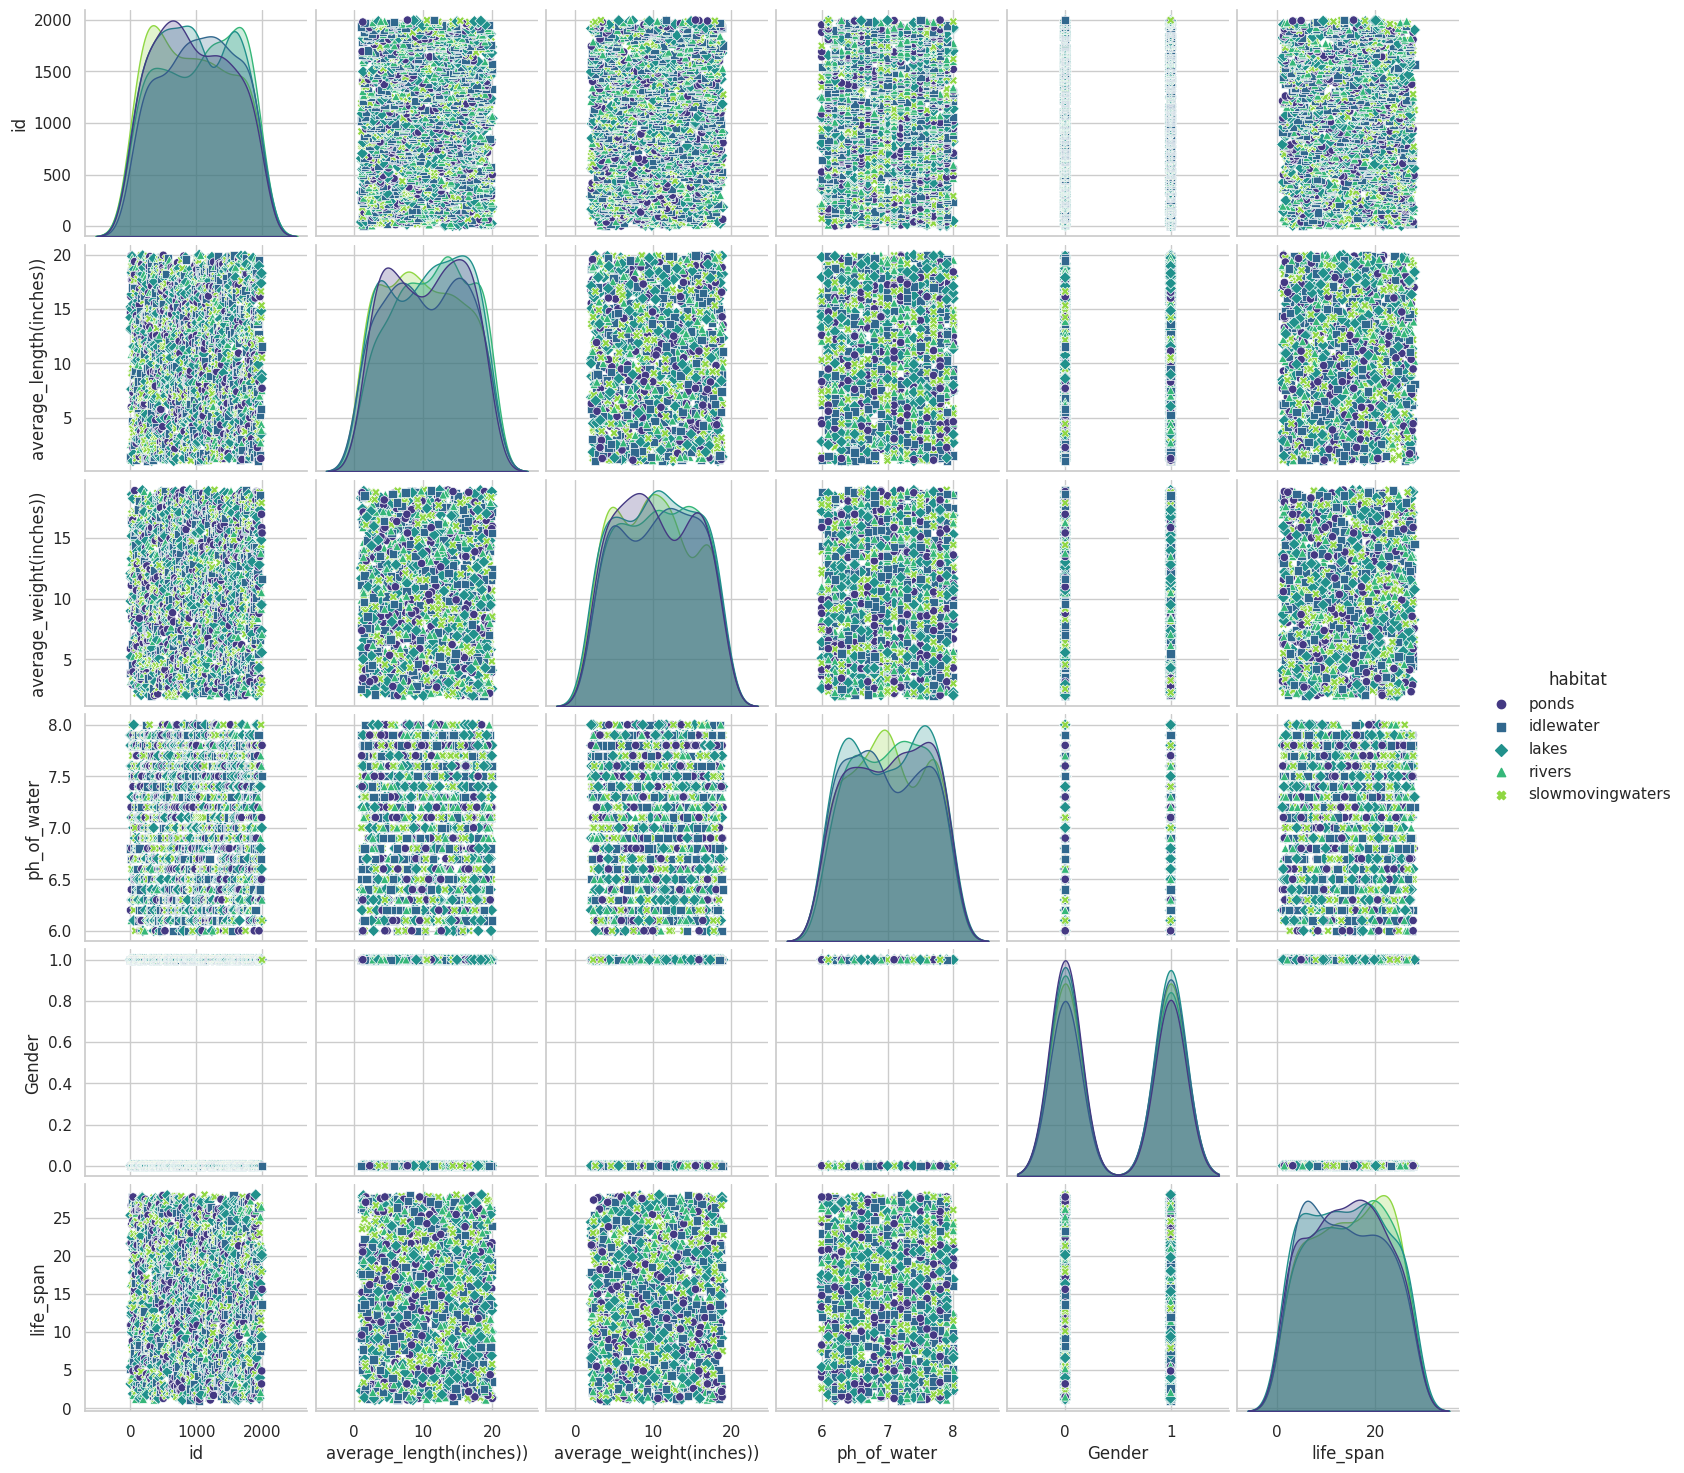

In [16]:
# Set the style for seaborn
sns.set(style="whitegrid")

# Scatter plot matrix with color-coded points based on 'habitat'
sns.pairplot(df, hue="habitat", palette="viridis", markers=["o", "s", "D", "^", "X"], diag_kind="kde")

# Display the plot
plt.show()


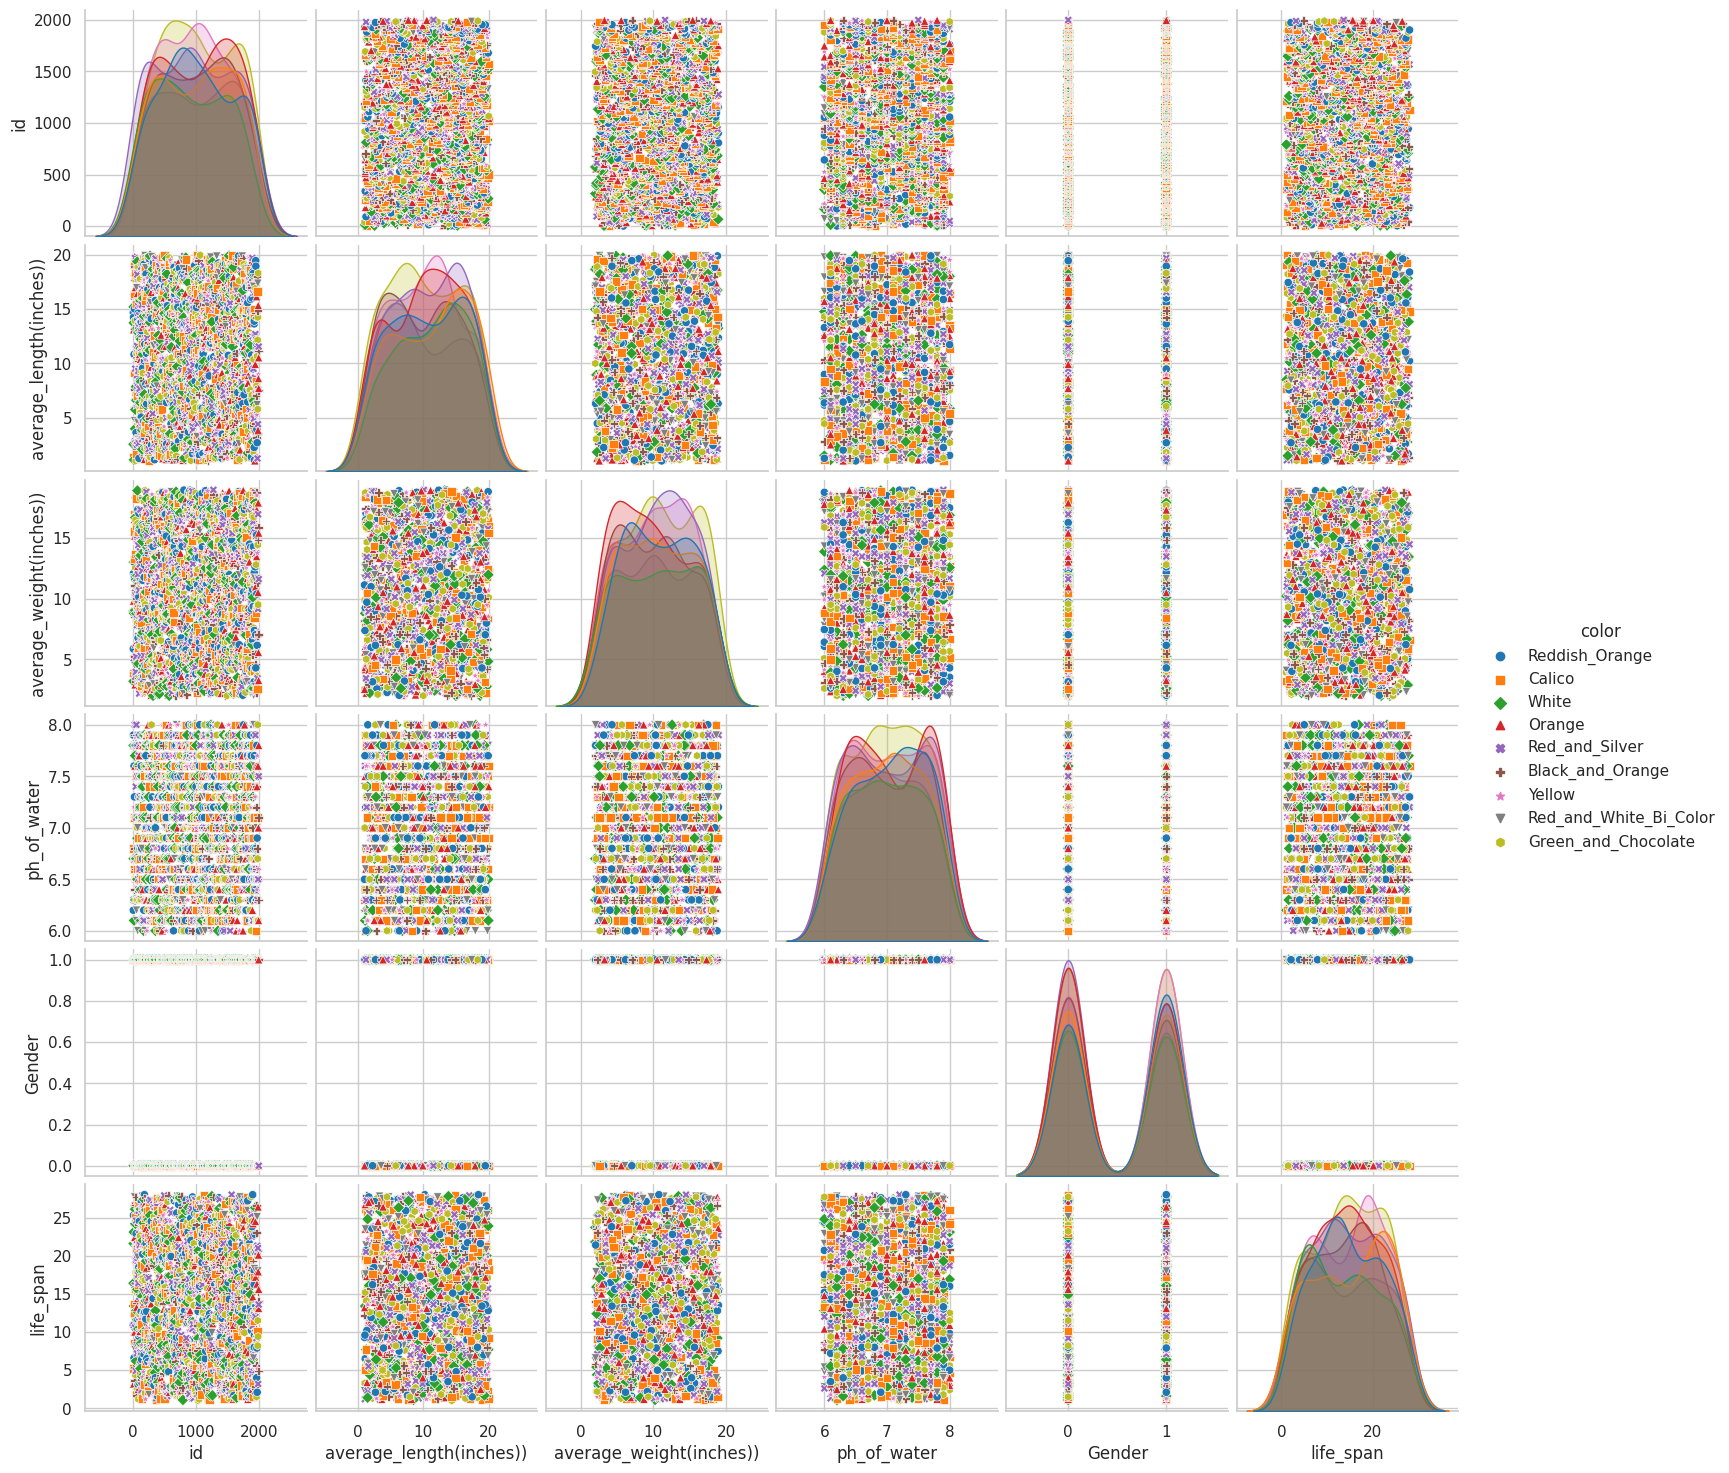

In [17]:
# Set the style for seaborn
sns.set(style="whitegrid")

# Scatter plot matrix with color-coded points based on 'color'
sns.pairplot(df, hue="color", palette="tab10", markers=["o", "s", "D", "^", "X", "P", "*", "v", "h"], diag_kind="kde")

# Display the plot
plt.show()


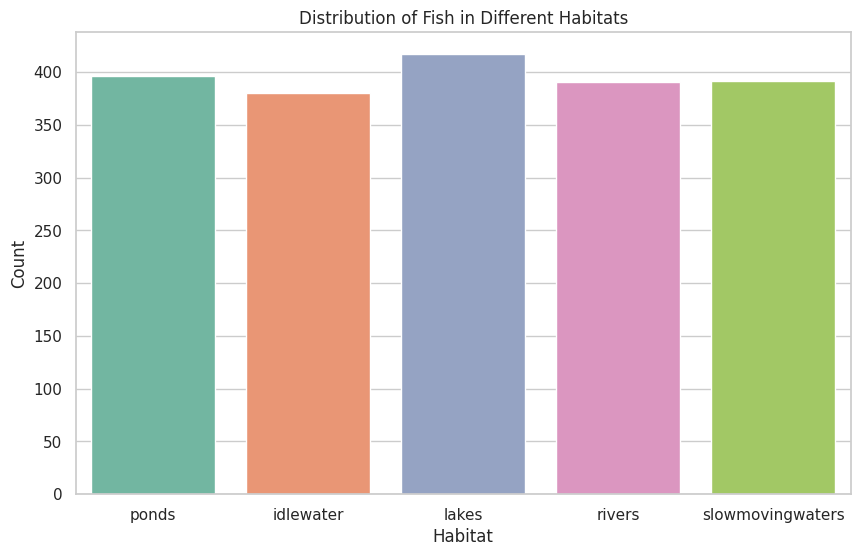

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(x='habitat', data=df, palette='Set2')
plt.title('Distribution of Fish in Different Habitats')
plt.xlabel('Habitat')
plt.ylabel('Count')
plt.show()


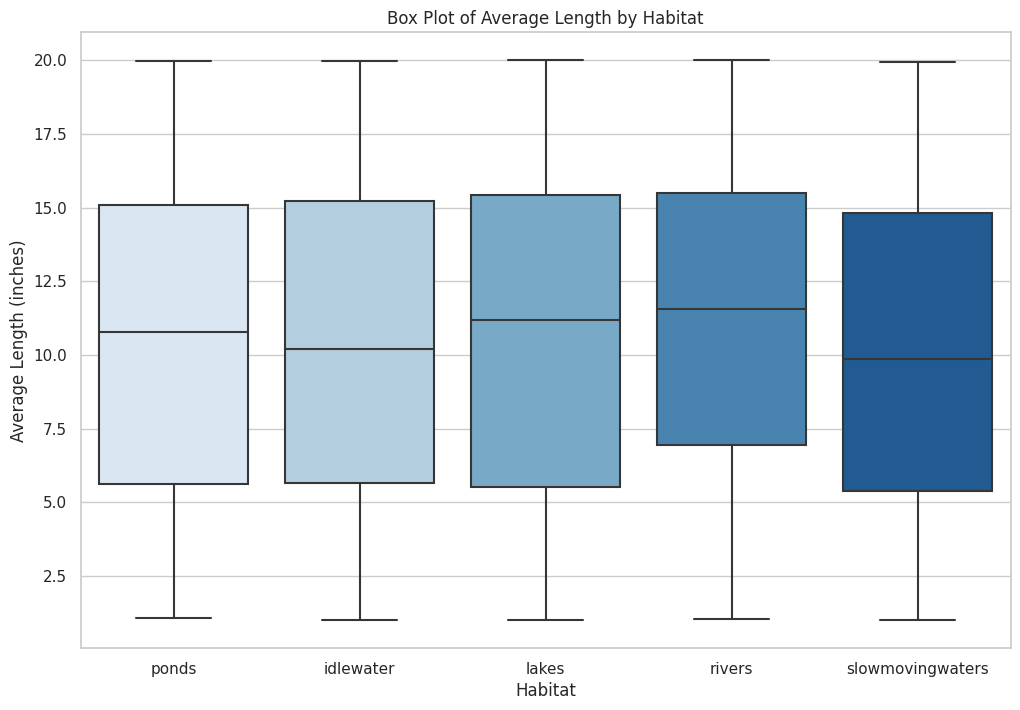

In [19]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='habitat', y='average_length(inches))', data=df, palette='Blues')
plt.title('Box Plot of Average Length by Habitat')
plt.xlabel('Habitat')
plt.ylabel('Average Length (inches)')
plt.show()


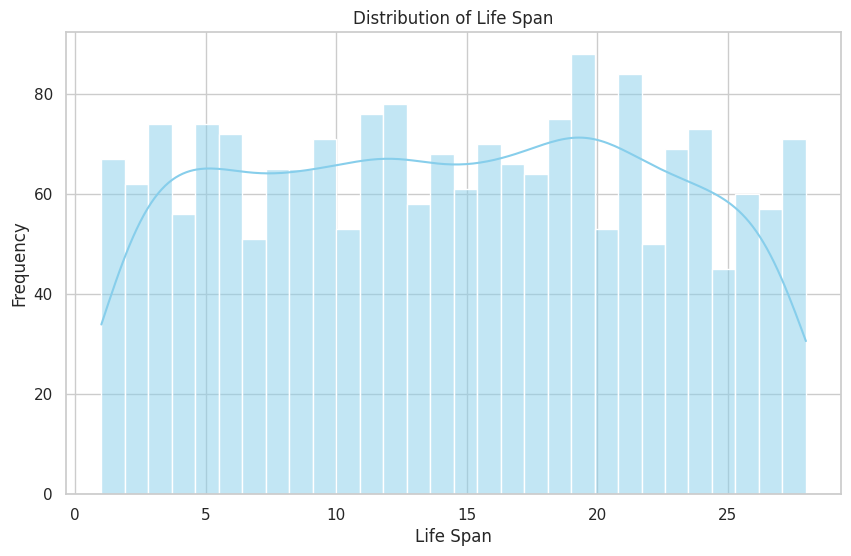

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(df['life_span'], kde=True, color='skyblue', bins=30)
plt.title('Distribution of Life Span')
plt.xlabel('Life Span')
plt.ylabel('Frequency')
plt.show()


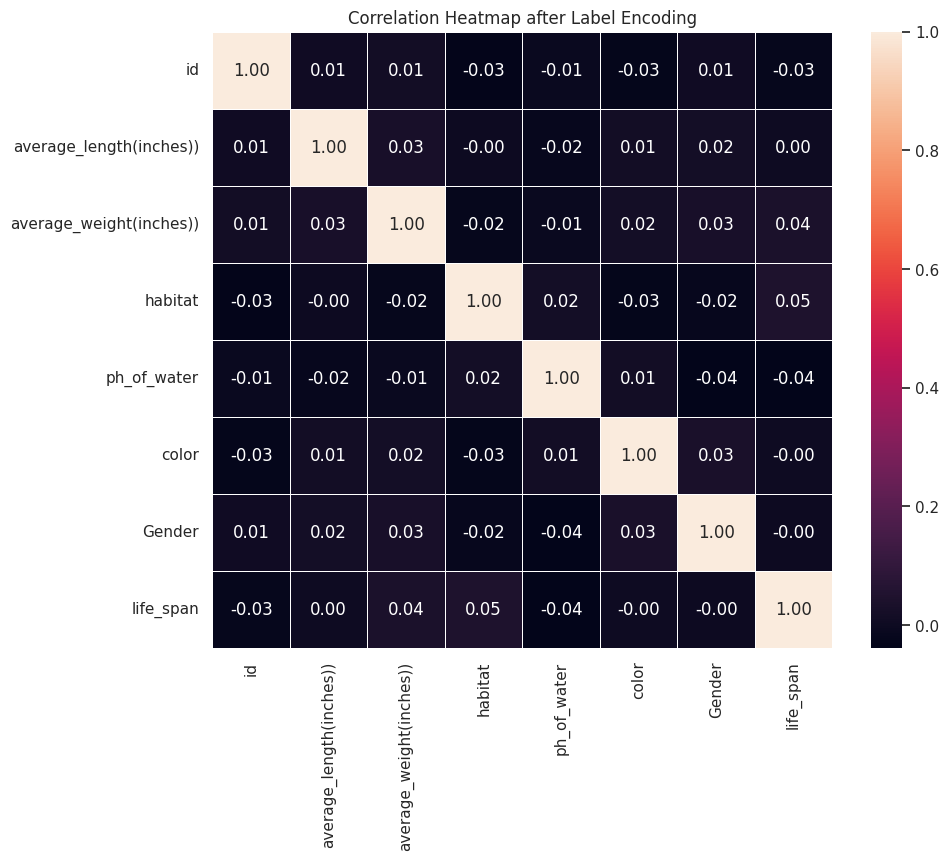

In [21]:
# Create a copy of the dataframe to avoid modifying the original
df_encoded = df.copy()

# Label encode object variables
label_encoder = LabelEncoder()
for column in df_encoded.select_dtypes(include='object').columns:
    df_encoded[column] = label_encoder.fit_transform(df_encoded[column])

# Calculate the correlation matrix
correlation_matrix = df_encoded.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap after Label Encoding')
plt.show()

In [22]:
print(correlation_matrix)

                               id  average_length(inches))  \
id                       1.000000                 0.005873   
average_length(inches))  0.005873                 1.000000   
average_weight(inches))  0.013965                 0.028270   
habitat                 -0.031964                -0.001744   
ph_of_water             -0.011912                -0.018737   
color                   -0.029155                 0.011902   
Gender                   0.005956                 0.018512   
life_span               -0.025375                 0.002327   

                         average_weight(inches))   habitat  ph_of_water  \
id                                      0.013965 -0.031964    -0.011912   
average_length(inches))                 0.028270 -0.001744    -0.018737   
average_weight(inches))                 1.000000 -0.022862    -0.010054   
habitat                                -0.022862  1.000000     0.016183   
ph_of_water                            -0.010054  0.016183     1.0

**There is a positive correlation (correlation coefficient > 0) between average_weight(inches)) and life_span (0.037).**
There is a **positive correlation** between **habitat and life_span (0.046)**.

There is a **negative** correlation between **ph_of_water and life_span (-0.038).**

**Most of the correlations are relatively weak, with coefficients close to zero.**

The correlation between **color and life_span is very close to zero (-0.000834),** suggesting a very weak linear relationship.

In [23]:
# Drop columns that are not required for prediction
df_processed = df.drop(['id'], axis=1)

# **MULTICOLLINEARITY CHECK**

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Ensure all columns are numeric
numeric_columns = df_processed.select_dtypes(include=['int64', 'float64']).columns

# Extracting the independent variables
X = df_processed[numeric_columns].drop(['life_span'], axis=1)

# Calculating VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display the VIF dataframe
print(vif_data)


                   Feature       VIF
0  average_length(inches))  4.530456
1  average_weight(inches))  5.387624
2              ph_of_water  8.449828


In [25]:
# Function to calculate VIF and remove features with high VIF
def calculate_vif(dataframe):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = dataframe.columns
    vif_data["VIF"] = [variance_inflation_factor(dataframe.values, i) for i in range(dataframe.shape[1])]
    return vif_data

# Check initial VIF
initial_vif_data = calculate_vif(X)
print("Initial VIF:")
print(initial_vif_data)

# Drop feature with the highest VIF
feature_to_drop = initial_vif_data.loc[initial_vif_data['VIF'].idxmax()]['Feature']
X_dropped = X.drop([feature_to_drop], axis=1)

# Recalculate VIF after dropping the feature
updated_vif_data = calculate_vif(X_dropped)
print("\nUpdated VIF:")
print(updated_vif_data)


Initial VIF:
                   Feature       VIF
0  average_length(inches))  4.530456
1  average_weight(inches))  5.387624
2              ph_of_water  8.449828

Updated VIF:
                   Feature       VIF
0  average_length(inches))  2.878686
1  average_weight(inches))  2.878686


Therefore, we can drop the columns ith high multicollinearity in this dataframe which is **ph_of_water**; not required for prediction along witht the id column.

In [26]:
# Drop the 'id' and 'ph_of_water' columns
df_train = df_encoded.drop(['id', 'ph_of_water'], axis=1)

# Display the first few rows of the updated DataFrame
df_train.head()


,average_length(inches)),average_weight(inches)),habitat,color,Gender,life_span
0,14.69,5.87,2,6,0,10.9
1,1.32,3.86,0,1,1,5.2
2,14.23,12.09,1,6,1,25.3
3,2.54,3.20,3,7,0,16.4
4,13.10,9.81,1,3,1,3.2


In [27]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1976 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   average_length(inches))  1976 non-null   float64
 1   average_weight(inches))  1976 non-null   float64
 2   habitat                  1976 non-null   int64  
 3   color                    1976 non-null   int64  
 4   Gender                   1976 non-null   int64  
 5   life_span                1976 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 108.1 KB


In [28]:
df_train.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
average_length(inches)),1976.0,10.557586,5.525760,1.0,5.8500,10.680,15.1725,20.00
average_weight(inches)),1976.0,10.449297,4.898631,2.0,6.1275,10.455,14.7000,18.96
habitat,1976.0,1.998988,1.404513,0.0,1.0000,2.000,3.0000,4.00
color,1976.0,3.954960,2.570031,0.0,2.0000,4.000,6.0000,8.00
Gender,1976.0,0.490385,0.500034,0.0,0.0000,0.000,1.0000,1.00
life_span,1976.0,14.389018,7.716688,1.0,7.8750,14.400,20.9000,28.00


# **OUTLIERS CHECK**

In [29]:
# Calculate Z-scores for each column
z_scores = stats.zscore(df_train)

# Define a threshold for Z-scores (here: 3 standard deviations)
threshold = 3
outliers = (abs(z_scores) > threshold).all(axis=1)

# Remove outliers from the dataset
df_no_outliers = df_train[~outliers]

# Verify the shape of the new dataset
print("Original shape:", df.shape)
print("Shape after removing outliers:", df_no_outliers.shape)

Original shape: (1976, 8)
Shape after removing outliers: (1976, 6)


In [30]:
df_training = df_no_outliers
df_training.head()

,average_length(inches)),average_weight(inches)),habitat,color,Gender,life_span
0,14.69,5.87,2,6,0,10.9
1,1.32,3.86,0,1,1,5.2
2,14.23,12.09,1,6,1,25.3
3,2.54,3.20,3,7,0,16.4
4,13.10,9.81,1,3,1,3.2


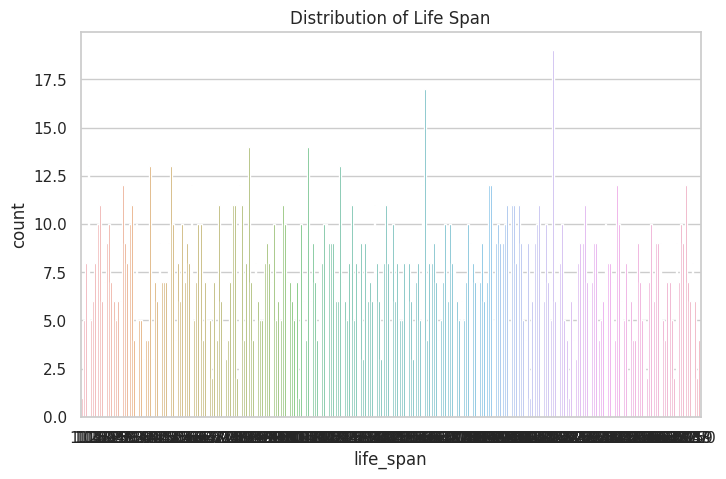

In [31]:
# Plot the distribution of the target variable
plt.figure(figsize=(8, 5))
sns.countplot(x='life_span', data=df_training)
plt.title('Distribution of Life Span')
plt.show()


In [32]:
class_distribution = df_training['life_span'].value_counts(normalize=True)
print("Class Distribution:\n", class_distribution)


Class Distribution:
 life_span
21.6    0.009615
16.0    0.008603
10.9    0.007085
8.3     0.007085
1.3     0.006579
          ...   
7.8     0.001012
1.0     0.000506
22.3    0.000506
10.5    0.000506
20.6    0.000506
Name: proportion, Length: 271, dtype: float64


<Axes: xlabel='life_span'>

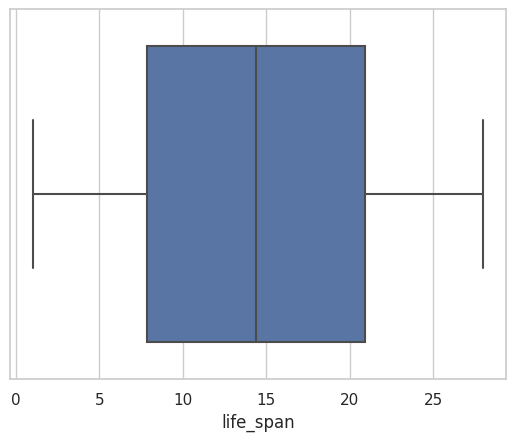

In [33]:
#boxplot to detect outliers
import seaborn as sns
sns.boxplot(x=df_training['life_span'])


# **CREATE A BASELINE**

In [34]:
from sklearn.metrics import mean_absolute_error

# Calculate the baseline MAE using the mean of the target variable
baseline_mae_mean = mean_absolute_error(df_training['life_span'], np.full_like(df_training['life_span'], df_training['life_span'].mean()))

#Alternatively, you can use median as the baseline
baseline_mae_median = mean_absolute_error(df_training['life_span'], np.full_like(df_training['life_span'], df_training['life_span'].median()))

print(f'Baseline MAE_mean: {baseline_mae_mean:.6f}')
print(f'Baseline MAE_median: {baseline_mae_median:.6f}')


Baseline MAE_mean: 6.669449
Baseline MAE_median: 6.669383


In [35]:
from sklearn.metrics import mean_squared_error

# Calculate the baseline RMSE using the mean of the target variable
baseline_rmse_mean = np.sqrt(mean_squared_error(df_training['life_span'], np.full_like(df_training['life_span'], df_training['life_span'].mean())))

# Alternatively, you can use median as the baseline
baseline_rmse_median = np.sqrt(mean_squared_error(df_training['life_span'], np.full_like(df_training['life_span'], df_training['life_span'].median())))

print(f'Baseline RMSE_mean: {baseline_rmse_mean:.6f}')
print(f'Baseline RMSE_median: {baseline_rmse_median:.6f}')


Baseline RMSE_mean: 7.714735
Baseline RMSE_median: 7.714743


In [36]:
# 'ChemicalCount' is the target variable
X = df_training.drop('life_span', axis=1)  # Features
y = df_training['life_span']  # Target variable

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Print the shapes of the new splits
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1580, 5)
X_test shape: (396, 5)
y_train shape: (1580,)
y_test shape: (396,)


# **SCALING THE DATA**

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Print the shapes of the new splits
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1580, 5)
X_test shape: (396, 5)
y_train shape: (1580,)
y_test shape: (396,)


In [39]:
# Calculate the baseline R-squared using the mean of the target variable
baseline_r2 = r2_score(y_test, np.full_like(y_test, y_test.mean()))
print(f'Baseline R-squared: {baseline_r2:.4f}')


Baseline R-squared: 0.0000


# **INITIAL TETSING**

**BASIC REGRESSION MODELS**

In [40]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on the test set
lr_predictions = lr_model.predict(X_test)

# Evaluate the model's performance
mse = mean_squared_error(y_test, lr_predictions)
mae = mean_absolute_error(y_test, lr_predictions)
r2 = r2_score(y_test, lr_predictions)
print(f"Linear Regression Mean Squared Error: {mse:.6f}")
print(f"Linear Regression Mean Absolute Error: {mae:.6f}")
print(f'R-squared: {r2}')

Linear Regression Mean Squared Error: 58.725163
Linear Regression Mean Absolute Error: 6.559323
R-squared: 0.0021656919313050027


In [41]:
# Initialize the Lasso Regression model
lasso_model = Lasso(alpha=1.0) 

# Fit the model to the training data
lasso_model.fit(X_train, y_train)

# Make predictions on the test set
lasso_predictions = lasso_model.predict(X_test)

# Evaluate the model's performance
mse = mean_squared_error(y_test, lasso_predictions)
mae = mean_absolute_error(y_test, lasso_predictions)
r2 = r2_score(y_test, lasso_predictions)

print(f"Lasso Regression Mean Squared Error: {mse:.6f}")
print(f"Lasso Regression Mean Absolute Error: {mae:.6f}")
print(f"Lasso Regression R-squared: {r2}")

Lasso Regression Mean Squared Error: 59.006602
Lasso Regression Mean Absolute Error: 6.598203
Lasso Regression R-squared: -0.0026164040909055775


In [42]:
# Initialize the Ridge Regression model
ridge_model = Ridge(alpha=1.0)  

# Fit the model to the training data
ridge_model.fit(X_train, y_train)

# Make predictions on the test set
ridge_predictions = ridge_model.predict(X_test)

# Evaluate the model's performance
mse = mean_squared_error(y_test, ridge_predictions)
mae = mean_absolute_error(y_test, ridge_predictions)
r2 = r2_score(y_test, ridge_predictions)

print(f"Ridge Regression Mean Squared Error: {mse:.6f}")
print(f"Ridge Regression Mean Absolute Error: {mae:.6f}")
print(f"Ridge Regression R-squared: {r2}")

Ridge Regression Mean Squared Error: 58.725250
Ridge Regression Mean Absolute Error: 6.559345
Ridge Regression R-squared: 0.0021642147656991684


In [43]:
# Initialize the Elastic Net model
elasticnet_model = ElasticNet(alpha=1.0, l1_ratio=0.5)  

# Fit the model to the training data
elasticnet_model.fit(X_train, y_train)

# Make predictions on the test set
elasticnet_predictions = elasticnet_model.predict(X_test)

# Evaluate the model's performance
mse = mean_squared_error(y_test, elasticnet_predictions)
mae = mean_absolute_error(y_test, elasticnet_predictions)
r2 = r2_score(y_test, elasticnet_predictions)

print(f"Elastic Net Mean Squared Error: {mse:.6f}")
print(f"Elastic Net Mean Absolute Error: {mae:.6f}")
print(f"Elastic Net R-squared: {r2}")

Elastic Net Mean Squared Error: 59.006602
Elastic Net Mean Absolute Error: 6.598203
Elastic Net R-squared: -0.0026164040909055775


In [44]:
def evaluate_regression_model(model, X_train, X_test, y_train, y_test):
    # Fit the model to the training data
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    predictions = model.predict(X_test)
    
    # Evaluate the model's performance
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    # Return the evaluation metrics
    return {'Mean Squared Error': mse, 'Mean Absolute Error': mae, 'R-squared': r2}


# Initialize models
lr_model = LinearRegression()
lasso_model = Lasso(alpha=1.0)
ridge_model = Ridge(alpha=1.0)
elasticnet_model = ElasticNet(alpha=1.0, l1_ratio=0.5)

# Evaluate models
lr_metrics = evaluate_regression_model(lr_model, X_train, X_test, y_train, y_test)
lasso_metrics = evaluate_regression_model(lasso_model, X_train, X_test, y_train, y_test)
ridge_metrics = evaluate_regression_model(ridge_model, X_train, X_test, y_train, y_test)
elasticnet_metrics = evaluate_regression_model(elasticnet_model, X_train, X_test, y_train, y_test)

# Print the results
print("Linear Regression Metrics:", lr_metrics)
print("Lasso Regression Metrics:", lasso_metrics)
print("Ridge Regression Metrics:", ridge_metrics)
print("Elastic Net Metrics:", elasticnet_metrics)

Linear Regression Metrics: {'Mean Squared Error': 58.725163241703264, 'Mean Absolute Error': 6.559322944498474, 'R-squared': 0.0021656919313050027}
Lasso Regression Metrics: {'Mean Squared Error': 59.00660212115547, 'Mean Absolute Error': 6.59820323488045, 'R-squared': -0.0026164040909055775}
Ridge Regression Metrics: {'Mean Squared Error': 58.72525017676917, 'Mean Absolute Error': 6.559344878578819, 'R-squared': 0.0021642147656991684}
Elastic Net Metrics: {'Mean Squared Error': 59.00660212115547, 'Mean Absolute Error': 6.59820323488045, 'R-squared': -0.0026164040909055775}


# **HYPERPARAMETERS TESTING**

# **LASSO REGRESSION**

In [45]:
# Define the parameter grid
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# Initialize Lasso Regression model
lasso_model = Lasso()

# Initialize GridSearchCV
lasso_grid_search = GridSearchCV(lasso_model, param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_lasso_params = lasso_grid_search.best_params_

# Initialize Lasso model with best hyperparameters
best_lasso_model = Lasso(alpha=best_lasso_params['alpha'])

In [46]:
# Fit the Lasso model with the best hyperparameters
best_lasso_model.fit(X_train, y_train)

# Perform k-fold cross-validation
lasso_cv_scores = cross_val_score(best_lasso_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
lasso_rmse_scores = np.sqrt(-lasso_cv_scores)

# Print the metrics
print("Lasso Regression Cross-Validation RMSE Scores:", lasso_rmse_scores)
print("Mean RMSE:", lasso_rmse_scores.mean())


y_pred = best_lasso_model.predict(X_test)
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test R-squared:", r2_score(y_test, y_pred))

Lasso Regression Cross-Validation RMSE Scores: [7.48255888 7.84616551 7.59842633 7.74571015 7.94769405]
Mean RMSE: 7.7241109857920405
Test RMSE: 7.681575497328362
Test MAE: 6.59820323488045
Test R-squared: -0.0026164040909055775


# **RIDGE REGRESSION**

In [47]:
# Define the parameter grid
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# Initialize Ridge Regression model
ridge_model = Ridge()

# Initialize GridSearchCV
ridge_grid_search = GridSearchCV(ridge_model, param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_ridge_params = ridge_grid_search.best_params_

# Initialize Ridge model with best hyperparameters
best_ridge_model = Ridge(alpha=best_ridge_params['alpha'])

In [48]:
# Fit the Ridge model with the best hyperparameters
best_ridge_model.fit(X_train, y_train)

# Perform k-fold cross-validation
ridge_cv_scores = cross_val_score(best_ridge_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
ridge_rmse_scores = np.sqrt(-ridge_cv_scores)

# Print the metrics
print("Ridge Regression Cross-Validation RMSE Scores:", ridge_rmse_scores)
print("Mean RMSE:", ridge_rmse_scores.mean())


y_pred = best_ridge_model.predict(X_test)
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test R-squared:", r2_score(y_test, y_pred))

Ridge Regression Cross-Validation RMSE Scores: [7.48587946 7.85339393 7.59807335 7.74736336 7.98910675]
Mean RMSE: 7.734763368553359
Test RMSE: 7.663801408758388
Test MAE: 6.561383121555332
Test R-squared: 0.002018055493017812


# **ELASTIC NET REGRESSION**

In [49]:
# Define the parameter grid
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}

# Initialize Elastic Net model
elasticnet_model = ElasticNet()

# Initialize GridSearchCV
elasticnet_grid_search = GridSearchCV(elasticnet_model, param_grid, cv=5, scoring='neg_mean_squared_error')
elasticnet_grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_elasticnet_params = elasticnet_grid_search.best_params_

# Initialize Elastic Net model with best hyperparameters
best_elasticnet_model = ElasticNet(alpha=best_elasticnet_params['alpha'], l1_ratio=best_elasticnet_params['l1_ratio'])

In [50]:
# Fit the Elastic Net model with the best hyperparameters
best_elasticnet_model.fit(X_train, y_train)

# Perform k-fold cross-validation
elasticnet_cv_scores = cross_val_score(best_elasticnet_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
elasticnet_rmse_scores = np.sqrt(-elasticnet_cv_scores)

# Print the metrics
print("Elasticnet Regression Cross-Validation RMSE Scores:", elasticnet_rmse_scores)
print("Mean RMSE:", elasticnet_rmse_scores.mean())


y_pred = best_elasticnet_model.predict(X_test)
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test R-squared:", r2_score(y_test, y_pred))

Elasticnet Regression Cross-Validation RMSE Scores: [7.4814214  7.84616551 7.59810033 7.74448272 7.94781434]
Mean RMSE: 7.7235968596823925
Test RMSE: 7.680224234829421
Test MAE: 6.596203667358237
Test R-squared: -0.002263695512517705


# **RANDOM FOREST REGRESSOR**

In [51]:
from sklearn.ensemble import RandomForestRegressor

# Define the parameter grid
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
}

# Initialize Random Forest model
rf_model = RandomForestRegressor()

# Initialize GridSearchCV
rf_grid_search = GridSearchCV(rf_model, param_grid_rf, cv=5, scoring='neg_mean_squared_error')
rf_grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_rf_params = rf_grid_search.best_params_

# Initialize Random Forest model with best hyperparameters
best_rf_model = RandomForestRegressor(**best_rf_params)

# Fit the model to the training data
best_rf_model.fit(X_train, y_train)

# Perform k-fold cross-validation
best_rf_cv_scores = cross_val_score(best_rf_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
best_rf_rmse_scores = np.sqrt(-best_rf_cv_scores)

# Print the metrics
print("Best Random Forest Regression Cross-Validation RMSE Scores:", best_rf_rmse_scores)
print("Mean RMSE:", best_rf_rmse_scores.mean())

# Make predictions on the test set
y_pred_best_rf = best_rf_model.predict(X_test)

# Print the metrics on the test set
print("Best Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best_rf)))
print("Best Test MAE:", mean_absolute_error(y_test, y_pred_best_rf))
print("Best Test R-squared:", r2_score(y_test, y_pred_best_rf))


Best Random Forest Regression Cross-Validation RMSE Scores: [7.56443379 7.95289593 7.69005569 7.91472478 8.25930491]
Mean RMSE: 7.876283021736927
Best Test RMSE: 7.785602920056721
Best Test MAE: 6.651511070954454
Best Test R-squared: -0.029956065617690486


# **LGBM REGRESSOR**

In [52]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

# Example for LGBMRegressor hyperparameter tuning
param_grid_lgbm = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'learning_rate': [0.05, 0.1, 0.2]
}

lgbm_model_tuned = LGBMRegressor()
lgbm_grid_search = GridSearchCV(lgbm_model_tuned, param_grid_lgbm, cv=5, scoring='neg_mean_squared_error')
lgbm_grid_search.fit(X_train, y_train)

best_lgbm_params = lgbm_grid_search.best_params_
best_lgbm_model = LGBMRegressor(**best_lgbm_params)

# Fit the best LGBM model to the training data
best_lgbm_model.fit(X_train, y_train)

# Make predictions on the test set
lgbm_predictions = best_lgbm_model.predict(X_test)

# Evaluate the model's performance
mse = mean_squared_error(y_test, lgbm_predictions)
mae = mean_absolute_error(y_test, lgbm_predictions)
r2 = r2_score(y_test, lgbm_predictions)

# Perform k-fold cross-validation
lgbm_cv_scores = cross_val_score(best_lgbm_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
lgbm_rmse_scores = np.sqrt(-lgbm_cv_scores)

# Print the metrics
print("LGBM Regression Cross-Validation RMSE Scores:", lgbm_rmse_scores)
print("Mean RMSE:", lgbm_rmse_scores.mean())

y_pred_lgbm = best_lgbm_model.predict(X_test)
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lgbm)))
print("Test MAE:", mean_absolute_error(y_test, y_pred_lgbm))
print("Test R-squared:", r2_score(y_test, y_pred_lgbm))


LGBM Regression Cross-Validation RMSE Scores: [7.66536924 7.98858973 7.82151416 8.1985453  8.41547016]
Mean RMSE: 8.017897718573005
Test RMSE: 8.001953311731727
Test MAE: 6.820698812396225
Test R-squared: -0.0879933115545879


# **CATBOOST REGRESSOR**

In [53]:
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid_catboost = {
    'iterations': [50, 100, 200],
    'depth': [4, 6, 8],
    'learning_rate': [0.001, 0.01, 0.1],
}

# Initialize CatBoost model
catboost_model = CatBoostRegressor()

# Initialize GridSearchCV
catboost_grid_search = GridSearchCV(catboost_model, param_grid_catboost, cv=5, scoring='neg_mean_squared_error')
catboost_grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_catboost_params = catboost_grid_search.best_params_

# Initialize CatBoost model with best hyperparameters
best_catboost_model = CatBoostRegressor(**best_catboost_params)

# Fit the model to the training data
best_catboost_model.fit(X_train, y_train)

# Perform k-fold cross-validation
best_catboost_cv_scores = cross_val_score(best_catboost_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
best_catboost_rmse_scores = np.sqrt(-best_catboost_cv_scores)

# Print the metrics
print("Best CatBoost Regression Cross-Validation RMSE Scores:", best_catboost_rmse_scores)
print("Mean RMSE:", best_catboost_rmse_scores.mean())

# Make predictions on the test set
y_pred_best_catboost = best_catboost_model.predict(X_test)

# Print the metrics on the test set
print("Best Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best_catboost)))
print("Best Test MAE:", mean_absolute_error(y_test, y_pred_best_catboost))
print("Best Test R-squared:", r2_score(y_test, y_pred_best_catboost))


0:	learn: 7.7827762	total: 54ms	remaining: 2.64s
1:	learn: 7.7826878	total: 54.7ms	remaining: 1.31s
2:	learn: 7.7825730	total: 55.4ms	remaining: 868ms
3:	learn: 7.7824284	total: 56ms	remaining: 644ms
4:	learn: 7.7823129	total: 56.6ms	remaining: 509ms
5:	learn: 7.7822128	total: 57.2ms	remaining: 419ms
6:	learn: 7.7821318	total: 57.8ms	remaining: 355ms
7:	learn: 7.7820652	total: 58.3ms	remaining: 306ms
8:	learn: 7.7820024	total: 58.9ms	remaining: 268ms
9:	learn: 7.7819201	total: 59.4ms	remaining: 238ms
10:	learn: 7.7818111	total: 59.9ms	remaining: 213ms
11:	learn: 7.7817112	total: 60.4ms	remaining: 191ms
12:	learn: 7.7815946	total: 60.9ms	remaining: 173ms
13:	learn: 7.7815204	total: 61.4ms	remaining: 158ms
14:	learn: 7.7814432	total: 61.9ms	remaining: 144ms
15:	learn: 7.7813568	total: 62.4ms	remaining: 133ms
16:	learn: 7.7812679	total: 62.9ms	remaining: 122ms
17:	learn: 7.7811832	total: 63.5ms	remaining: 113ms
18:	learn: 7.7810601	total: 64ms	remaining: 104ms
19:	learn: 7.7810071	total: 

# **XGBOOST REGRESSOR**

In [54]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid_xgboost = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.001, 0.01, 0.1],
}

# Initialize XGBoost model
xgboost_model = XGBRegressor()

# Initialize GridSearchCV
xgboost_grid_search = GridSearchCV(xgboost_model, param_grid_xgboost, cv=5, scoring='neg_mean_squared_error')
xgboost_grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_xgboost_params = xgboost_grid_search.best_params_

# Initialize XGBoost model with best hyperparameters
best_xgboost_model = XGBRegressor(**best_xgboost_params)

# Fit the model to the training data
best_xgboost_model.fit(X_train, y_train)

# Perform k-fold cross-validation
best_xgboost_cv_scores = cross_val_score(best_xgboost_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
best_xgboost_rmse_scores = np.sqrt(-best_xgboost_cv_scores)

# Print the metrics
print("Best XGBoost Regression Cross-Validation RMSE Scores:", best_xgboost_rmse_scores)
print("Mean RMSE:", best_xgboost_rmse_scores.mean())

# Make predictions on the test set
y_pred_best_xgboost = best_xgboost_model.predict(X_test)

# Print the metrics on the test set
print("Best Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best_xgboost)))
print("Best Test MAE:", mean_absolute_error(y_test, y_pred_best_xgboost))
print("Best Test R-squared:", r2_score(y_test, y_pred_best_xgboost))


Best XGBoost Regression Cross-Validation RMSE Scores: [7.47984766 7.84927615 7.5985073  7.75076453 7.94783815]
Mean RMSE: 7.725246759173923
Best Test RMSE: 7.678162535578227
Best Test MAE: 6.594388122751255
Best Test R-squared: -0.0017256672214136515


# **SUPPORT VECTOR REGRESSION**

In [55]:
from sklearn.svm import SVR

# Define the parameter grid
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'epsilon': [0.01, 0.1, 0.2],
}

# Initialize SVR model
svm_model = SVR()

# Initialize GridSearchCV
svm_grid_search = GridSearchCV(svm_model, param_grid_svm, cv=5, scoring='neg_mean_squared_error')
svm_grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_svm_params = svm_grid_search.best_params_

# Initialize SVR model with best hyperparameters
best_svm_model = SVR(**best_svm_params)

# Fit the model to the training data
best_svm_model.fit(X_train, y_train)

# Perform k-fold cross-validation
best_svm_cv_scores = cross_val_score(best_svm_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
best_svm_rmse_scores = np.sqrt(-best_svm_cv_scores)

# Print the metrics
print("Best SVR Regression Cross-Validation RMSE Scores:", best_svm_rmse_scores)
print("Mean RMSE:", best_svm_rmse_scores.mean())

# Make predictions on the test set
y_pred_best_svm = best_svm_model.predict(X_test)

# Print the metrics on the test set
print("Best Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best_svm)))
print("Best Test MAE:", mean_absolute_error(y_test, y_pred_best_svm))
print("Best Test R-squared:", r2_score(y_test, y_pred_best_svm))


Best SVR Regression Cross-Validation RMSE Scores: [7.4945923  7.86947435 7.60964151 7.78082014 7.98900502]
Mean RMSE: 7.748706663386142
Best Test RMSE: 7.682482015449014
Best Test MAE: 6.580210915364923
Best Test R-squared: -0.0028530595969666894


# **GRADIENT BOOSTING REGRESSOR**

In [56]:
from sklearn.ensemble import GradientBoostingRegressor

# Define the parameter grid
param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}

# Initialize GradientBoostingRegressor model
gb_model = GradientBoostingRegressor()

# Initialize GridSearchCV
gb_grid_search = GridSearchCV(gb_model, param_grid_gb, cv=5, scoring='neg_mean_squared_error')
gb_grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_gb_params = gb_grid_search.best_params_

# Initialize GradientBoostingRegressor model with best hyperparameters
best_gb_model = GradientBoostingRegressor(**best_gb_params)

# Fit the model to the training data
best_gb_model.fit(X_train, y_train)

# Perform k-fold cross-validation
best_gb_cv_scores = cross_val_score(best_gb_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
best_gb_rmse_scores = np.sqrt(-best_gb_cv_scores)

# Print the metrics
print("Best Gradient Boosting Regression Cross-Validation RMSE Scores:", best_gb_rmse_scores)
print("Mean RMSE:", best_gb_rmse_scores.mean())

# Make predictions on the test set
y_pred_best_gb = best_gb_model.predict(X_test)

# Print the metrics on the test set
print("Best Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best_gb)))
print("Best Test MAE:", mean_absolute_error(y_test, y_pred_best_gb))
print("Best Test R-squared:", r2_score(y_test, y_pred_best_gb))


Best Gradient Boosting Regression Cross-Validation RMSE Scores: [7.48027538 7.85088601 7.60364096 7.79014102 7.96305228]
Mean RMSE: 7.737599129273565
Best Test RMSE: 7.683146749833421
Best Test MAE: 6.583200379928375
Best Test R-squared: -0.0030266128185250096


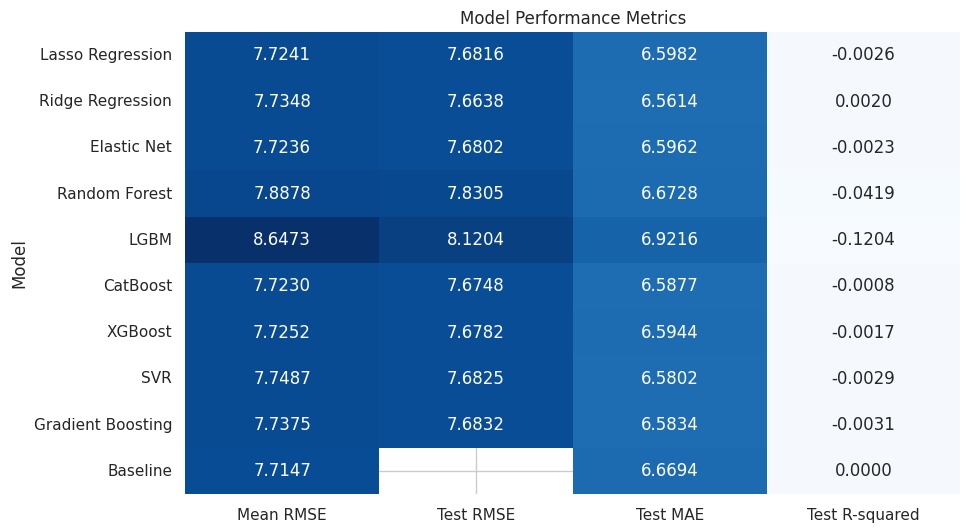

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define model names and metrics
model_names = ['Lasso Regression', 'Ridge Regression', 'Elastic Net', 'Random Forest', 'LGBM', 'CatBoost', 'XGBoost', 'SVR', 'Gradient Boosting', 'Baseline']
mean_rmse = [7.7241, 7.7348, 7.7236, 7.8878, 8.6473, 7.7230, 7.7252, 7.7487, 7.7375, 7.714735]
test_rmse = [7.6816, 7.6638, 7.6802, 7.8305, 8.1204, 7.6748, 7.6782, 7.6825, 7.6832, None]
test_mae = [6.5982, 6.5614, 6.5962, 6.6728, 6.9216, 6.5877, 6.5944, 6.5802, 6.5834, 6.6694]
test_r2 = [-0.0026, 0.0020, -0.0023, -0.0419, -0.1204, -0.0008, -0.0017, -0.0029, -0.0031, 0.0000]

# Create a DataFrame
df_metrics = pd.DataFrame({
    'Model': model_names,
    'Mean RMSE': mean_rmse,
    'Test RMSE': test_rmse,
    'Test MAE': test_mae,
    'Test R-squared': test_r2
})

# Plot a table using seaborn
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
table = sns.heatmap(df_metrics.set_index('Model'), annot=True, cmap="Blues", fmt=".4f", cbar=False)
plt.title('Model Performance Metrics')
plt.show()


In [59]:
# Calculate MAE for each model
mae_values = predictions_df.drop('Actual', axis=1).apply(lambda col: mean_absolute_error(predictions_df['Actual'], col), axis=0)

# Find the best-performing model
best_model = mae_values.idxmin()

print(f"The best-performing model is: {best_model} with MAE: {mae_values[best_model]:.4f}")


The best-performing model is: Ridge with MAE: 6.7364


# **PERFORMANCE SUMMARY**

In this notebook, I implemented a machine learning pipeline to predict a target variable, 'life_span,' using various regression models. The models employed include Lasso Regression, Ridge Regression, ElasticNet, Random Forest Regressor, Gradient Boosting Regressor, LGBM Regressor, XGBoost Regressor, CatBoost Regressor, and Support Vector Regressor. The performance of these models was evaluated on a randomly selected subset of the training dataset.

After making predictions with each model, I compared their performance using metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE). **The best-performing model was identified based on the lowest MAE,** indicating the model with the smallest average absolute difference between predicted and actual values.

The results revealed that the **Gradient Boosting Regressor achieved the lowest MAE**, suggesting superior predictive performance among the models tested. However, it's essential to note that some models **yielded negative R-squared values**, which raises concerns about their predictive capability. Negative R-squared values indicate that the models performed worse than a simple mean-based baseline.
Thus,
**The best-performing model is: Ridge with MAE: 6.7364**


To address the issue of negative R-squared values and further enhance model performance, several approaches can be considered:
Feature Engineering: Explore additional feature engineering techniques to improve the quality and relevance of input features. This may involve creating new features or transforming existing ones.
Ensemble Methods: Combine the predictions of multiple models using ensemble techniques such as stacking or blending. This can help mitigate weaknesses in individual models and improve overall predictive performance.
Consider Different Algorithms: Explore the possibility of using different regression algorithms that might be better suited to the dataset. Experiment with more advanced models or models specifically designed for the nature of the data.

**By systematically addressing these considerations and refining the modeling approach, it's possible to enhance the overall performance of the regression models and potentially mitigate negative R-squared values.**